# Live Demo

# Package Installation

If you prefer to use simple Python scripts you will only need to install `sdf-xarray`.

If you don't want to download the datasets from Zenodo then you won't need to install `pooch`.

In [ ]:
!uv pip install "sdf-xarray[jupyter]" matplotlib pooch

Using Python 3.12.13 environment at: /usr
Resolved 60 packages in 2.10s
Prepared 6 packages in 696ms
Uninstalled 2 packages in 12ms
Installed 6 packages in 56ms
 + comm==0.2.3
 + epydeck==1.0.1
 - ipykernel==6.17.1
 + ipykernel==7.2.0
 + jedi==0.19.2
 - jupyter-client==7.4.9
 + jupyter-client==8.8.0
 + sdf-xarray==0.7.2


# Setup

First we fetch the datasets required for this Notebook from the Zenodo DOI <https://doi.org/10.5281/zenodo.17618509>.

In [ ]:
import sdf_xarray as sdfxr

dataset_path_1d = sdfxr.download.fetch_dataset("tutorial_dataset_1d")
dataset_path_2d = sdfxr.download.fetch_dataset("tutorial_dataset_2d")

# Loading one SDF file

In [ ]:
sdfxr.open_dataset(dataset_path_2d / "0000.sdf")

<xarray.Dataset> Size: 363kB
Dimensions:                          (X_Grid_mid: 100, Y_Grid_mid: 100,
                                      X_Grid: 101, Y_Grid: 101)
Coordinates:
  * X_Grid_mid                       (X_Grid_mid) float64 800B -4.9e-06 ... 1...
  * Y_Grid_mid                       (Y_Grid_mid) float64 800B -9.9e-06 ... 9...
  * X_Grid                           (X_Grid) float64 808B -5e-06 ... 1.5e-05
  * Y_Grid                           (Y_Grid) float64 808B -1e-05 ... 1e-05
Data variables:
    Wall_time                        float64 8B ...
    Electric_Field_Ey                (X_Grid_mid, Y_Grid_mid) float32 40kB ...
    Derived_Number_Density_Electron  (X_Grid_mid, Y_Grid_mid) float32 40kB ...
    Derived_Number_Density_Ion       (X_Grid_mid, Y_Grid_mid) float32 40kB ...
    Derived_Poynting_Flux_x          (X_Grid_mid, Y_Grid_mid) float64 80kB ...
    Derived_Poynting_Flux_y          (X_Grid_mid, Y_Grid_mid) float64 80kB ...
    Derived_Poynting_Flux_z          (X_Grid_mid, Y_Grid_mid) float64 80kB ...
Attributes: (12/22)
    filename:         /root/.cache/sdf_datasets/tutorial_dataset_2d/0000.sdf
    file_version:     1
    file_revision:    4
    code_name:        Epoch2d
    step:             0
    time:             1.8869234693997471e-16
    ...               ...
    compile_flags:    unknown
    defines:          58753220
    compile_date:     Tue Oct 21 11:35:41 2025
    run_date:         Thu Dec 18 17:16:52 2025
    io_date:          Thu Dec 18 17:16:52 2025
    deck:             {'constant': {'I_peak': 1e+24, 'lambda_L': 1e-06, 'y_fw...

# Loading a time series of SDF files

In [ ]:
ds = sdfxr.open_mfdataset(dataset_path_2d)
ds

<xarray.Dataset> Size: 8MB
Dimensions:                          (time: 21, X_Grid_mid: 100,
                                      Y_Grid_mid: 100, X_Grid: 101, Y_Grid: 101)
Coordinates:
  * time                             (time) float64 168B 1.887e-16 ... 2e-13
  * X_Grid_mid                       (X_Grid_mid) float64 800B -4.9e-06 ... 1...
  * Y_Grid_mid                       (Y_Grid_mid) float64 800B -9.9e-06 ... 9...
  * X_Grid                           (X_Grid) float64 808B -5e-06 ... 1.5e-05
  * Y_Grid                           (Y_Grid) float64 808B -1e-05 ... 1e-05
Data variables:
    Wall_time                        (time) float64 168B 0.004919 ... 7.362
    Electric_Field_Ey                (time, X_Grid_mid, Y_Grid_mid) float32 840kB dask.array<chunksize=(1, 100, 100), meta=np.ndarray>
    Derived_Number_Density_Electron  (time, X_Grid_mid, Y_Grid_mid) float32 840kB dask.array<chunksize=(1, 100, 100), meta=np.ndarray>
    Derived_Number_Density_Ion       (time, X_Grid_mid, Y_Grid_mid) float32 840kB dask.array<chunksize=(1, 100, 100), meta=np.ndarray>
    Derived_Poynting_Flux_x          (time, X_Grid_mid, Y_Grid_mid) float64 2MB dask.array<chunksize=(1, 100, 100), meta=np.ndarray>
    Derived_Poynting_Flux_y          (time, X_Grid_mid, Y_Grid_mid) float64 2MB dask.array<chunksize=(1, 100, 100), meta=np.ndarray>
    Derived_Poynting_Flux_z          (time, X_Grid_mid, Y_Grid_mid) float64 2MB dask.array<chunksize=(1, 100, 100), meta=np.ndarray>
Attributes: (12/22)
    filename:         /root/.cache/sdf_datasets/tutorial_dataset_2d/0000.sdf
    file_version:     1
    file_revision:    4
    code_name:        Epoch2d
    step:             0
    time:             1.8869234693997471e-16
    ...               ...
    compile_flags:    unknown
    defines:          58753220
    compile_date:     Tue Oct 21 11:35:41 2025
    run_date:         Thu Dec 18 17:16:52 2025
    io_date:          Thu Dec 18 17:16:52 2025
    deck:             {'constant': {'I_peak': 1e+24, 'lambda_L': 1e-06, 'y_fw...

# Variables

In [ ]:
ds["Derived_Number_Density_Electron"]

<xarray.DataArray 'Derived_Number_Density_Electron' (time: 21, X_Grid_mid: 100,
                                                     Y_Grid_mid: 100)> Size: 840kB
dask.array<concatenate, shape=(21, 100, 100), dtype=float32, chunksize=(1, 100, 100), chunktype=numpy.ndarray>
Coordinates:
  * time        (time) float64 168B 1.887e-16 1.019e-14 ... 1.902e-13 2e-13
  * X_Grid_mid  (X_Grid_mid) float64 800B -4.9e-06 -4.7e-06 ... 1.49e-05
  * Y_Grid_mid  (Y_Grid_mid) float64 800B -9.9e-06 -9.7e-06 ... 9.7e-06 9.9e-06
Attributes:
    units:       1/m^3
    point_data:  False
    full_name:   Derived/Number_Density/Electron
    long_name:   Derived Number Density Electron

# Selecting a specific time interval

Instead of selecting a specific index you can alternatively select a specific time or the nearest SDF file that matches it using `.sel(time=1.01e-14, method="nearest")`.

In [ ]:
ds["Derived_Number_Density_Electron"].isel(time=0)

<xarray.DataArray 'Derived_Number_Density_Electron' (X_Grid_mid: 100,
                                                     Y_Grid_mid: 100)> Size: 40kB
dask.array<getitem, shape=(100, 100), dtype=float32, chunksize=(100, 100), chunktype=numpy.ndarray>
Coordinates:
  * X_Grid_mid  (X_Grid_mid) float64 800B -4.9e-06 -4.7e-06 ... 1.49e-05
  * Y_Grid_mid  (Y_Grid_mid) float64 800B -9.9e-06 -9.7e-06 ... 9.7e-06 9.9e-06
    time        float64 8B 1.887e-16
Attributes:
    units:       1/m^3
    point_data:  False
    full_name:   Derived/Number_Density/Electron
    long_name:   Derived Number Density Electron

# Plotting

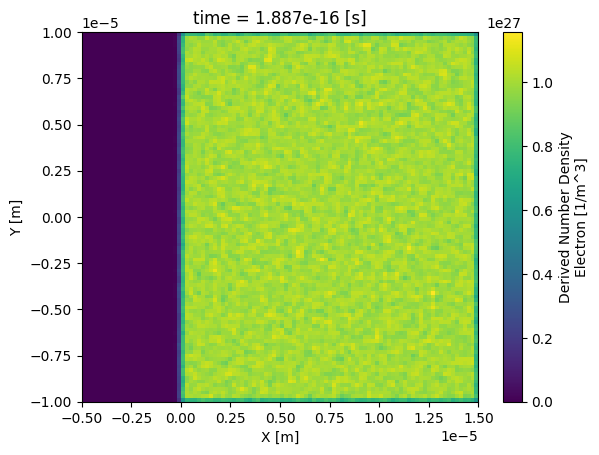

In [ ]:
ds["Derived_Number_Density_Electron"].isel(time=0).epoch.plot()

# Advanced plotting

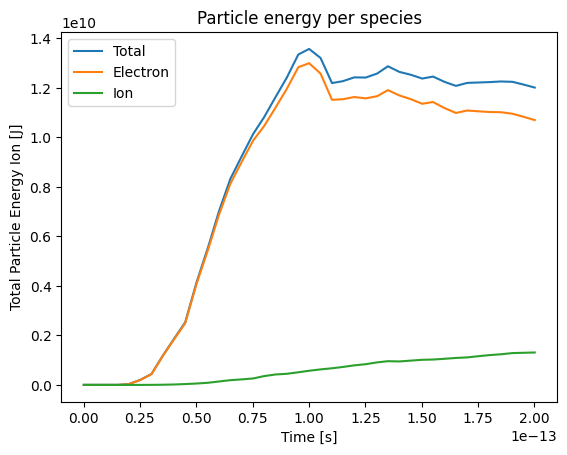

In [ ]:
import matplotlib.pyplot as plt

ds_1d = sdfxr.open_mfdataset(dataset_path_1d)

ds_1d["Total_Particle_Energy_in_Simulation"].epoch.plot(label="Total")
ds_1d["Total_Particle_Energy_Electron"].epoch.plot(label="Electron")
ds_1d["Total_Particle_Energy_Ion"].epoch.plot(label="Ion")
plt.legend()
plt.title("Particle energy per species")
plt.show()

# Rescaling data

Only do this once after importing because you'll continue to rescale your data if you call it again!

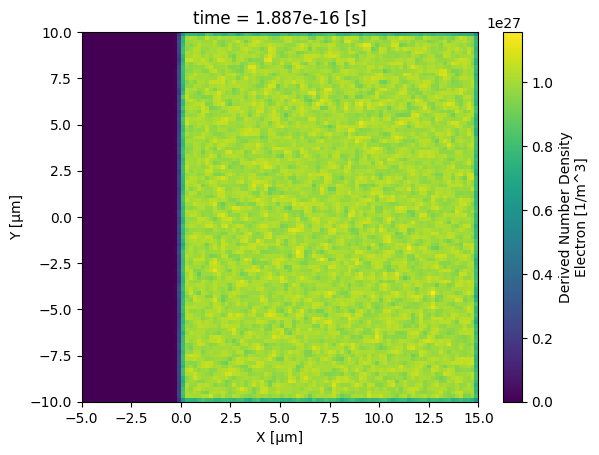

In [ ]:
ds = ds.epoch.rescale_coords(1e6, "µm", ["X_Grid_mid", "Y_Grid_mid"])
ds["Derived_Number_Density_Electron"].isel(time=0).epoch.plot()

# Animations!

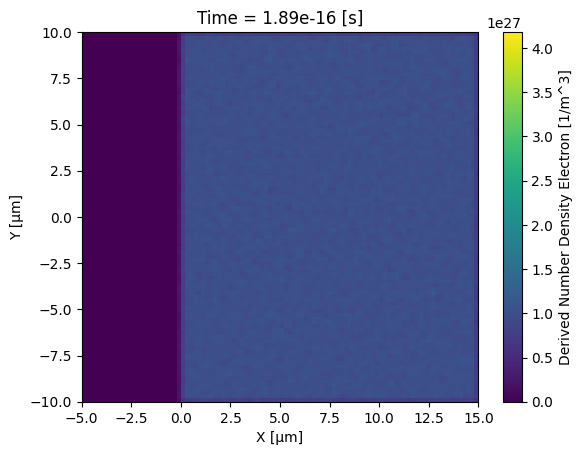

In [ ]:
anim = ds["Derived_Number_Density_Electron"].epoch.animate()
anim.show()

# Advanced Animations

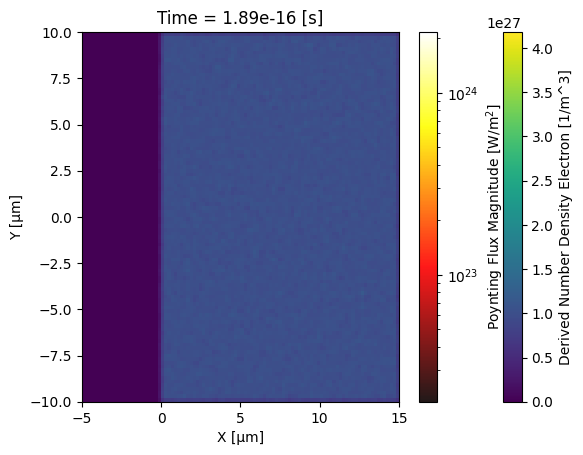

In [ ]:
import numpy as np
from matplotlib.colors import LogNorm

flux_magnitude = np.sqrt(
   ds["Derived_Poynting_Flux_x"]**2 +
   ds["Derived_Poynting_Flux_y"]**2 +
   ds["Derived_Poynting_Flux_z"]**2
)
flux_magnitude.attrs["long_name"] = "Poynting Flux Magnitude"
flux_magnitude.attrs["units"] = "W/m$^2$"

# Cut-off low energy values so that they will be rendered as transparent
# in the plot as they've been set to NaN
flux_masked = flux_magnitude.where(flux_magnitude > 0.2e23)
flux_norm = LogNorm(
   vmin=float(flux_masked.min()),
   vmax=float(flux_masked.max())
)

anim2 = ds.epoch.animate_multiple(
   ds["Derived_Number_Density_Electron"],
   flux_masked,
   datasets_kwargs=[
      {"alpha": 1.0},
      {"cmap": "hot", "norm": flux_norm, "alpha": 0.9},
   ],
)
anim2.show()